In [3]:
LOGS_PATH = {
    # "SFace (Baseline)": "logs/sface_baseline.log",
    # "SFace + KD (SFace OpenCV)": "logs/sface_kd_sface_onnx.log",
    # "SFace + KD (ArcFace)": "logs/sface_kd_arcface.log",
    "Head (CASIA + real) ": "logs/head-casia_real.log",
}

train_logs = {}

for log_name, log_path in LOGS_PATH.items():
    train_logs[log_name] = {
        "epoch": [],
        "intra_loss": [],
        "inter_loss": [],
        "Wyi": [],
        "Wj": [],
        "Prec1": [],
        "CosineLoss": [],
    }

    with open(log_path, "r") as fi:
        while True:
            line = fi.readline()

            if line == "":
                break
            if not line.startswith("Epoch"):
                continue

            blocks = line.strip(" \n\t").split("\t")

            epoch = int(blocks[0].split(" ")[1])
            intra_loss = float(blocks[2].split(" ")[-1].strip("()"))
            inter_loss = float(blocks[3].split(" ")[-1].strip("()"))
            Wyi = float(blocks[4].split(" ")[-1].strip("()"))
            Wj = float(blocks[5].split(" ")[-1].strip("()"))
            Prec1 = float(blocks[6].split(" ")[-1].strip("()"))

            if (
                len(train_logs[log_name]["epoch"]) == 0
                or train_logs[log_name]["epoch"][-1] != epoch
            ):
                train_logs[log_name]["epoch"].append(epoch)
                train_logs[log_name]["intra_loss"].append(intra_loss)
                train_logs[log_name]["inter_loss"].append(inter_loss)
                train_logs[log_name]["Wyi"].append(Wyi)
                train_logs[log_name]["Wj"].append(Wj)
                train_logs[log_name]["Prec1"].append(Prec1)

                if len(blocks) > 7:
                    CosineLoss = float(blocks[7].split(" ")[-1].strip("()"))
                    train_logs[log_name]["CosineLoss"].append(CosineLoss)
            else:
                train_logs[log_name]["intra_loss"][-1] = intra_loss
                train_logs[log_name]["inter_loss"][-1] = inter_loss
                train_logs[log_name]["Wyi"][-1] = Wyi
                train_logs[log_name]["Wj"][-1] = Wj
                train_logs[log_name]["Prec1"][-1] = Prec1

                if len(blocks) > 7:
                    train_logs[log_name]["CosineLoss"][-1] = float(
                        blocks[7].split(" ")[-1].strip("()")
                    )
        fi.close()

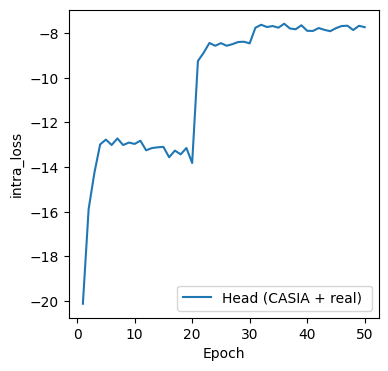

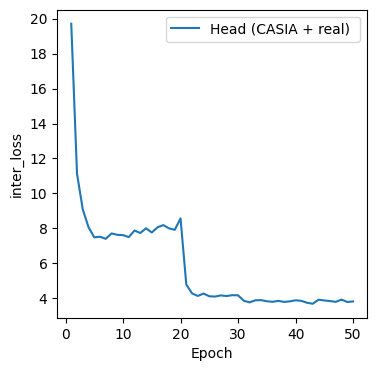

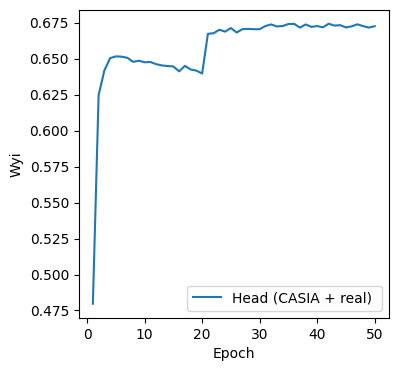

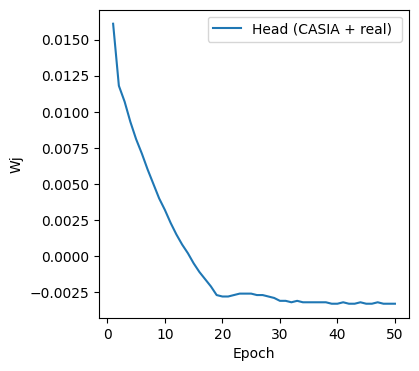

In [4]:
import matplotlib.pyplot as plt


def plot_train_loss(names: list[str], key: str, save_path: str = None):
    plt.figure(figsize=(4, 4))
    for name in names:
        plt.plot(
            train_logs[name]["epoch"],
            train_logs[name][key],
            label=name,
        )
    plt.xlabel("Epoch")
    plt.ylabel(key)
    plt.legend()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.plot()


plot_train_loss(list(train_logs.keys()), "intra_loss")
plot_train_loss(list(train_logs.keys()), "inter_loss")
plot_train_loss(list(train_logs.keys()), "Wyi")
plot_train_loss(list(train_logs.keys()), "Wj")